# Tier 3 · Notebook 17 — Parallelism (Data / Tensor / Pipeline / FSDP)

> **Goal:** understand the four strategies for training a model too big — or on data too big — for a single GPU: **data**, **tensor**, **pipeline**, and **sharded (FSDP/ZeRO)** parallelism. We simulate each with tiny NumPy "devices" to *prove the math reassembles correctly*, and reason about the memory and communication tradeoffs.

**Why parallelism.** A single modern GPU has ~80 GB. A 70-billion-parameter model in fp16 needs ~140 GB *just for weights* — and training needs several× more for gradients and optimizer state (Adam keeps 2 extra copies). So training large models **must** split work across many GPUs. The four strategies split along different axes; real systems combine them ("3D parallelism"). We can't use real multi-GPU here, so we simulate each "device" as a slice of NumPy arrays and verify the distributed computation equals the single-device one — which is the whole correctness requirement.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)
print("We'll simulate N 'devices' as N array-shards in one process, and check results match single-device.")


We'll simulate N 'devices' as N array-shards in one process, and check results match single-device.


## 1. Data parallelism — replicate the model, split the batch

The simplest and most common. Each of $N$ devices holds a **full copy** of the model but processes a **different slice of the batch**. After the backward pass, devices **all-reduce** (average) their gradients so every replica applies the *same* update and stays in sync.

The key correctness fact: **averaging the per-device gradients equals the gradient of the full batch** (because the loss is a mean over examples, and the gradient of a mean is the mean of gradients). Let's verify.


In [2]:
# a tiny linear model: loss = mean over batch of (x@w - y)^2 ; grad wrt w
X = np.random.randn(32, 4); y = np.random.randn(32); w = np.random.randn(4)
def grad_full(X, y, w):
    pred = X @ w; return 2 * X.T @ (pred - y) / len(y)     # gradient of MSE

g_single = grad_full(X, y, w)                               # one device, full batch

# data-parallel: split batch across 4 devices, each computes its local gradient, then average
N = 4
shards = np.array_split(np.arange(32), N)
local_grads = [grad_full(X[s], y[s], w) for s in shards]
g_dataparallel = np.mean(local_grads, axis=0)               # the "all-reduce" (average)

print("single-device gradient:", np.round(g_single, 5))
print("data-parallel (avg):   ", np.round(g_dataparallel, 5))
print("max abs err:", np.abs(g_single - g_dataparallel).max())
assert np.allclose(g_single, g_dataparallel)
print("✅ averaging per-device gradients == full-batch gradient (data parallelism is exact)")


single-device gradient: [-0.85482  5.3418   2.27281 -0.44339]
data-parallel (avg):    [-0.85482  5.3418   2.27281 -0.44339]
max abs err: 4.440892098500626e-16
✅ averaging per-device gradients == full-batch gradient (data parallelism is exact)


**What to notice.** The averaged per-device gradient is **identical** to the full-batch gradient — so data parallelism is mathematically exact; it just spreads the batch across devices to go faster (more throughput). Its cost is **communication**: every step must all-reduce the *entire gradient* across all devices, and its limit is **memory** — each device still holds the whole model, so data parallelism alone can't train a model bigger than one GPU. That's what the next three strategies address. (Note: this exactness requires care with BatchNorm, which couples the batch — another reason LayerNorm is nicer for distributed training.)


## 2. Tensor parallelism — split a single layer across devices

When the model itself is too big, **tensor parallelism** splits *individual weight matrices* across devices. Take a matmul $Y = XW$ with a huge $W$. Split $W$ by **columns** into $[W_1, W_2]$ across 2 devices; each computes $Y_k = XW_k$ (a slice of the output), then the pieces are **concatenated** (an all-gather). For the *next* matmul, split by **rows** so the outputs get **summed** (an all-reduce) — this row/column pairing is exactly how Megatron-LM splits the transformer MLP and attention. Let's verify a column-split matmul reassembles.


In [3]:
X = np.random.randn(8, 16)     # (batch, d_in)
W = np.random.randn(16, 32)    # (d_in, d_out) — the "huge" matrix to split
Y_single = X @ W

# tensor-parallel: split W by columns across 2 devices, each computes a slice of Y, then concat
W1, W2 = W[:, :16], W[:, 16:]              # device 0 gets first half of output, device 1 the rest
Y1, Y2 = X @ W1, X @ W2                     # computed on separate devices
Y_tp = np.concatenate([Y1, Y2], axis=1)    # all-gather (concatenate output shards)
print("column-split matmul, max abs err:", np.abs(Y_single - Y_tp).max())
assert np.allclose(Y_single, Y_tp)

# the paired row-split for the *following* layer: outputs get summed (all-reduce)
Z = np.random.randn(32, 8)
Z1, Z2 = Z[:16], Z[16:]                     # split the second matrix by rows
out_single = Y_single @ Z
out_tp = Y1 @ Z1 + Y2 @ Z2                  # each device multiplies its shard, results are SUMMED
print("row-split matmul (summed), max abs err:", np.abs(out_single - out_tp).max())
assert np.allclose(out_single, out_tp)
print("✅ tensor parallelism reassembles exactly (column-split → concat, row-split → sum)")


column-split matmul, max abs err: 0.0
row-split matmul (summed), max abs err: 1.4210854715202004e-14
✅ tensor parallelism reassembles exactly (column-split → concat, row-split → sum)


**What to notice.** Splitting a weight matrix across devices and recombining (concatenate for column-split, **sum** for row-split) reproduces the single-device result exactly. This lets a layer bigger than one GPU's memory be computed across several. The cost: **heavy communication within every layer** (an all-reduce per layer), so tensor parallelism is used *within a node* where GPUs have fast interconnect (NVLink), typically limited to 8-way. It shrinks the per-device *weight* memory, unlike data parallelism.


## 3. Pipeline parallelism — split layers across devices (and the bubble)

**Pipeline parallelism** puts *different layers* on different devices: device 0 holds layers 1–4, device 1 holds layers 5–8, etc. A batch flows through like an assembly line. The catch: naively, device 1 sits **idle** while device 0 processes the first layers — this idle time is the **pipeline bubble**. The fix is to split the batch into **micro-batches** and stagger them so all devices stay busy, shrinking the bubble. Let's simulate the schedule and measure the bubble.


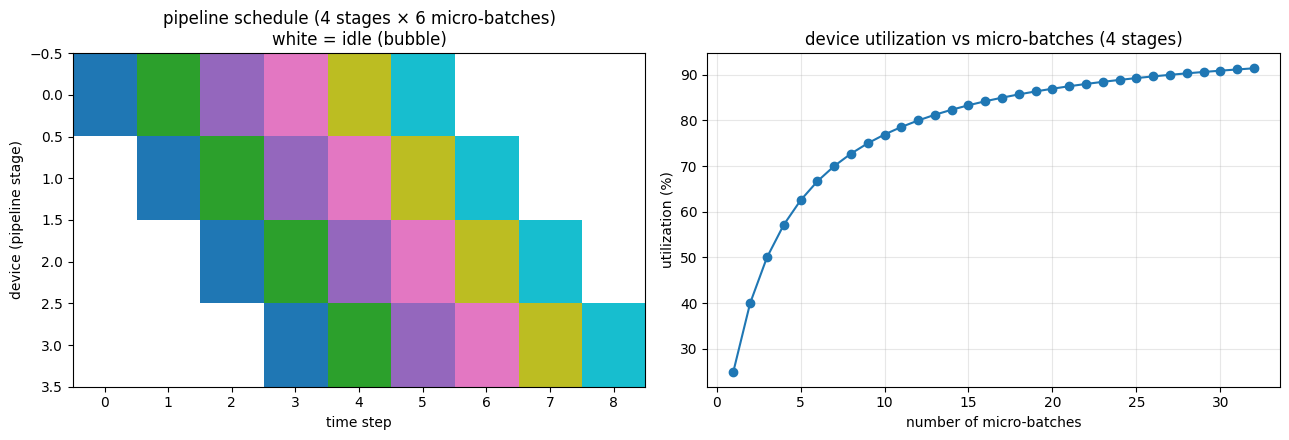

utilization with 1 micro-batch: 25%  (big bubble)
utilization with 16 micro-batches: 84%  (bubble mostly hidden)


In [4]:
def pipeline_utilization(n_stages, n_microbatches):
    # each (stage, microbatch) is one unit of work; a stage can only start micro-batch m
    # after the previous stage finished it. Total time = (stages + microbatches - 1) steps.
    total_steps = n_stages + n_microbatches - 1
    busy = n_stages * n_microbatches          # actual work units
    capacity = n_stages * total_steps          # device-steps available
    return busy / capacity, total_steps

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
# (a) a Gantt-style schedule for 4 stages, 6 micro-batches
stages, mb = 4, 6
grid = np.full((stages, stages+mb-1), np.nan)
for s in range(stages):
    for m in range(mb):
        grid[s, s+m] = m               # stage s works on micro-batch m at time s+m
ax[0].imshow(grid, cmap="tab10", aspect="auto")
ax[0].set_title("pipeline schedule (4 stages × 6 micro-batches)\nwhite = idle (bubble)")
ax[0].set_xlabel("time step"); ax[0].set_ylabel("device (pipeline stage)")

# (b) bubble fraction shrinks as micro-batches increase
mbs = np.arange(1, 33)
util = [pipeline_utilization(4, m)[0] for m in mbs]
ax[1].plot(mbs, np.array(util)*100, "-o", color="tab:blue")
ax[1].set_title("device utilization vs micro-batches (4 stages)")
ax[1].set_xlabel("number of micro-batches"); ax[1].set_ylabel("utilization (%)"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
u1, _ = pipeline_utilization(4, 1); u16, _ = pipeline_utilization(4, 16)
print(f"utilization with 1 micro-batch: {u1*100:.0f}%  (big bubble)")
print(f"utilization with 16 micro-batches: {u16*100:.0f}%  (bubble mostly hidden)")


**What to notice.** Left: the schedule shows each device (row) working on a staggered stream of micro-batches; the white cells at the start/end are the **bubble** (idle time while the pipeline fills and drains). Right: with just 1 micro-batch, utilization is only ~25% (3 of 4 devices idle most of the time — a huge waste); pushing more micro-batches through amortizes the fixed fill/drain, driving utilization toward 100%. This is why pipeline parallelism always uses many micro-batches. It splits **layers** (so per-device memory drops with depth) and communicates only *between adjacent stages* (cheap), making it good for crossing *between* nodes.


## 4. Sharded parallelism (FSDP / ZeRO) — split the optimizer state too

Data parallelism replicates *everything* on every device — wasteful, because each device stores a full copy of the weights, gradients, *and* optimizer state. **ZeRO / FSDP** (Fully Sharded Data Parallel) instead **shards** these across devices: each device permanently owns only $1/N$ of the parameters, gradients, and optimizer state, and **gathers** the full weights of a layer *just in time* for its forward/backward, then frees them. Same math as data parallelism, but the memory per device drops ~$N\times$.

The memory math is the punchline. With Adam in mixed precision, per parameter you store: fp16 weight (2B) + fp16 gradient (2B) + fp32 master weight (4B) + fp32 Adam momentum (4B) + fp32 Adam variance (4B) = **16 bytes/param**. Let's see how sharding across devices slashes this.


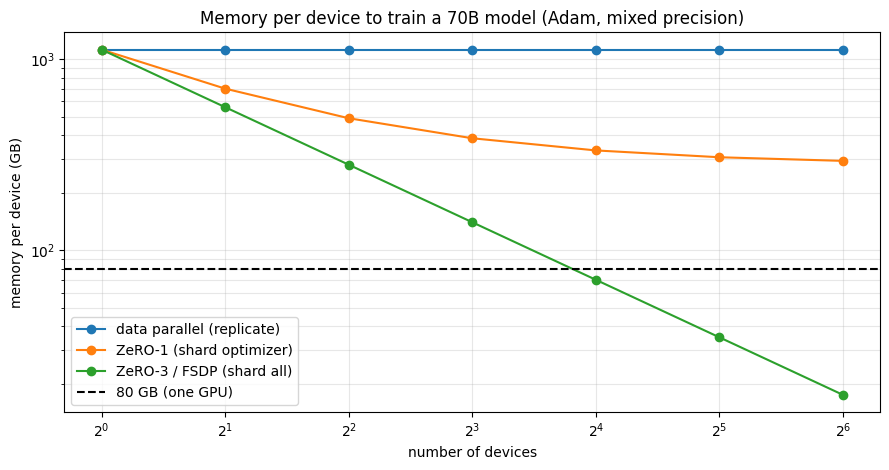

70B model, plain data-parallel: 1120 GB/device (impossible on 80GB!)
70B model, FSDP across 64 devices: 18 GB/device (fits!)


In [5]:
def mem_per_device_gb(n_params_billion, n_devices, strategy):
    P = n_params_billion * 1e9
    bytes_per_param = 16   # fp16 w + fp16 g + fp32 master + fp32 m + fp32 v (Adam mixed precision)
    if strategy == "data parallel (replicate)":
        return P * bytes_per_param / 1e9                 # every device stores everything
    elif strategy == "ZeRO-1 (shard optimizer)":
        return (P*4 + P*12/n_devices) / 1e9              # weights+grad replicated, opt sharded
    elif strategy == "ZeRO-3 / FSDP (shard all)":
        return P * bytes_per_param / n_devices / 1e9     # everything sharded

n_params = 70    # 70B model
devices = [1, 2, 4, 8, 16, 32, 64]
fig, ax = plt.subplots(figsize=(9, 4.8))
for strat in ["data parallel (replicate)", "ZeRO-1 (shard optimizer)", "ZeRO-3 / FSDP (shard all)"]:
    ax.plot(devices, [mem_per_device_gb(n_params, d, strat) for d in devices], "-o", label=strat)
ax.axhline(80, ls="--", color="k", label="80 GB (one GPU)")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_title("Memory per device to train a 70B model (Adam, mixed precision)")
ax.set_xlabel("number of devices"); ax.set_ylabel("memory per device (GB)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print(f"70B model, plain data-parallel: {mem_per_device_gb(70,8,'data parallel (replicate)'):.0f} GB/device (impossible on 80GB!)")
print(f"70B model, FSDP across 64 devices: {mem_per_device_gb(70,64,'ZeRO-3 / FSDP (shard all)'):.0f} GB/device (fits!)")


**What to notice.** Plain data parallelism needs **1120 GB per device** for a 70B model (16 B/param × 70 B) — impossible; every device stores the full 16×. Sharding the optimizer state (ZeRO-1) already helps a lot, and fully sharding weights+grads+optimizer (ZeRO-3/FSDP) makes per-device memory drop nearly linearly with device count, so 64 devices bring it to a comfortable ~18 GB. The cost is **communication**: FSDP must all-gather each layer's weights just before using them and reduce-scatter gradients after — more communication than plain data parallelism, but it's what makes training huge models feasible. FSDP/ZeRO is the workhorse of modern large-model training.

## 5. Putting it together: 3D parallelism
Real frontier training combines all of these:
- **Tensor parallelism** *within* a node (8 GPUs, fast NVLink) — splits each layer.
- **Pipeline parallelism** *across* a few nodes — splits the layer stack.
- **Data/FSDP parallelism** *across* many such groups — splits the batch and shards state.
A 70B+ model on thousands of GPUs uses a carefully-tuned mix, chosen to balance each strategy's memory savings against its communication cost. Knowing *which axis each strategy splits* (batch / within-layer / across-layers / state) and *what it communicates* (gradient all-reduce / activation all-reduce / stage hand-off / weight all-gather) is the mental model.

## 6. What you built / learned
- **Data parallelism**: replicate model, split batch, average gradients (exact); limited by per-device memory.
- **Tensor parallelism**: split weight matrices (column→concat, row→sum); heavy in-layer comms, use within a node.
- **Pipeline parallelism**: split layers into stages; micro-batches shrink the idle **bubble**.
- **FSDP / ZeRO**: shard weights + grads + optimizer state; ~$N\times$ less memory per device; more communication.
- **3D parallelism**: combine all three axes for frontier-scale training.

## 7. Exercises
1. **Gradient accumulation.** Simulate accumulating gradients over $k$ micro-batches on one device; show it equals a $k\times$ larger batch. (This is "poor man's data parallelism.")
2. **Communication volume.** For each strategy, compute bytes communicated per step as a function of model size and device count. Which scales worst?
3. **Bubble formula.** Derive the pipeline bubble fraction $= (\text{stages}-1)/(\text{stages}-1+\text{microbatches})$ and match it to the plot.
4. **ZeRO stages.** Implement the memory formulas for ZeRO-1, ZeRO-2, ZeRO-3 separately and compare.
5. **Overlap.** Real systems overlap communication with computation. Sketch how FSDP prefetches the next layer's weights during the current layer's compute.
6. **Choose a config.** For a 13B model on 16×80GB GPUs, propose a parallelism config and justify the memory/comms tradeoff.

## 8. Interview / residency framing
- *"Data vs tensor vs pipeline parallelism?"* → data splits the *batch* (replicate model), tensor splits *within a layer*, pipeline splits *across layers*; each communicates differently.
- *"Why is plain data parallelism not enough for big models?"* → every device stores the full model + grads + optimizer state; can't fit a model bigger than one GPU.
- *"What is the pipeline bubble and how do you reduce it?"* → idle time while the pipeline fills/drains; more micro-batches amortize it toward full utilization.
- *"What does ZeRO/FSDP do?"* → shards weights, gradients, and optimizer state across devices (gather-on-demand); ~$N\times$ memory reduction, more communication.
- *"3D parallelism?"* → tensor (in-node) × pipeline (across nodes) × data/FSDP (across groups), tuned to balance memory vs comms.

---
**Next:** *Tier 3 · Notebook 18 — Scaling laws*: reproduce a mini Chinchilla-style experiment showing loss falls as a predictable power law in model size, data, and compute — the empirical foundation of "just make it bigger."


## 📚 References & papers

This notebook reproduces / builds on:

- **Megatron-LM: Training Multi-Billion Parameter Language Models using Model Parallelism (tensor parallelism)** — Shoeybi et al. (2019), arXiv:1909.08053.
- **GPipe: Efficient Training of Giant Neural Networks using Pipeline Parallelism** — Huang et al. (2019), arXiv:1811.06965.
- **ZeRO: Memory Optimizations Toward Training Trillion Parameter Models** — Rajbhandari et al. (2020), arXiv:1910.02054.
- **PyTorch FSDP: Experiences on Scaling Fully Sharded Data Parallel** — Zhao et al. (2023), arXiv:2304.11277.